# Testing Stacking Ensembling Method

In [ ]:
# Core data libraries
import pandas as pd
import numpy as np

# Model persistence
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff

# Explainability
import shap

# Scikit-learn: preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OrdinalEncoder,
    FunctionTransformer
)

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    StackingClassifier,
    RandomForestClassifier
)

# Scikit-learn: model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

# Scikit-learn: metrics
from sklearn.metrics import (
    f1_score,
    classification_report
)

# XGBoost
import xgboost as xgb

# Custom utilities
from utils import custom_feature_engineering

Bringing in the SVM model

In [3]:
# ==========================================
# LOAD PIPELINE
# ==========================================
def load_svm_pipeline(path="../pipelines/svm_pipeline.pkl"):
    return joblib.load(path)


# ==========================================
# PREDICT FUNCTION
# Accepts raw test data as DataFrame
# ==========================================
def predict_svm(X_test, path="../pipelines/svm_pipeline.pkl"):
    """
    Predict labels using saved SVM pipeline.

    Parameters
    ----------
    X_test : pd.DataFrame
        Raw input data containing required columns:
        - Class
        - Inflight wifi service
        - Online boarding
        - Inflight entertainment
        - On-board service
        - Type of Travel

    path : str
        Path to saved pipeline

    Returns
    -------
    np.ndarray
        Predicted labels
    """
    model = load_svm_pipeline(path)
    return model.predict(X_test)


# ==========================================
# OPTIONAL: PROBABILITY-LIKE SCORES
# (distance to decision boundary)
# Useful for ensembling / stacking
# ==========================================
def predict_svm_scores(X_test, path="../pipelines/svm_pipeline.pkl"):
    """
    Returns decision scores for ensemble use.
    Higher = stronger confidence toward positive class.
    """
    model = load_svm_pipeline(path)
    return model.decision_function(X_test)

Defining the models:

In [ ]:
svm_model = load_svm_pipeline()


# adding filler models and preprocessing for now - will replace with actual trained models once ready 
categorical_features = ["Class", "Type of Travel"]
numeric_features = [
    "Inflight wifi service",
    "Online boarding",
    "Inflight entertainment",
    "On-board service"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), categorical_features),

        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

log_reg = joblib.load("../pipelines/logistic_regression_pipeline.pkl")


xgb_pipe = joblib.load("../pipelines/xgb_pipeline.pkl")

/Users/juliabunescu/.pyenv/versions/3.13.5/lib/python3.13/pickle.py:1760: UserWarning:

[23:24:44] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.




Performing the stacking with meta model a logistic regression:

In [5]:
stack_model = StackingClassifier(
    estimators=[
        ("svm", svm_model),
        ("lr", log_reg),
        ("xgb", xgb_pipe)
    ],
    final_estimator=LogisticRegression(),
    passthrough=False,  # only base predictions used
    cv=5,
    n_jobs=-1
)

Train the stacking model: (this took about 12m)

In [6]:
train_df = pd.read_csv("../data/train.csv", index_col=0)
X_train = train_df.drop(columns=["satisfaction", "id"])
y_train = train_df["satisfaction"]

stack_model.fit(X_train, y_train)

/Users/juliabunescu/venvs/generic/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [23:24:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[23:30:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[23:30:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[23:30:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[23:30:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[23:30:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.



,estimators,"[('svm', ...), ('lr', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None


Testing the stacked model:

In [7]:
test_df = pd.read_csv("../data/test.csv", index_col=0)
X_test = test_df.drop(columns=["satisfaction", "id"])
y_test = test_df["satisfaction"]

This took about  1m

In [8]:
preds = stack_model.predict(X_test)

print("Stacking F1 Macro:", f1_score(y_test, preds, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Stacking F1 Macro: 0.9626189765510025

Classification Report:

                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     14573
              satisfied       0.97      0.95      0.96     11403

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



## Meta-model coefficient importance

In [9]:
meta_model = stack_model.final_estimator_

feature_names = ["svm", "lr", "xgb"]

weights = meta_model.coef_[0]

fig = px.bar(
    x=feature_names, 
    y=weights,
    labels={'x': 'Feature', 'y': 'Weight'},
    title="Stacking Meta-Model Feature Weights"
)

fig.show()

## SHAP explainer on the meta model

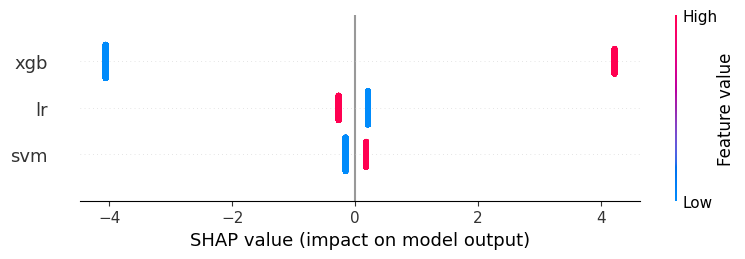

In [10]:
svm_pred = stack_model.named_estimators_["svm"].predict(X_test)
lr_pred = stack_model.named_estimators_["lr"].predict(X_test)
xgb_pred = stack_model.named_estimators_["xgb"].predict(X_test)

X_meta = pd.DataFrame({
    "svm": svm_pred,
    "lr": lr_pred,
    "xgb": xgb_pred
})

meta_model = stack_model.final_estimator_

explainer = shap.LinearExplainer(meta_model, X_meta)
shap_values = explainer(X_meta)

shap.summary_plot(shap_values, X_meta)

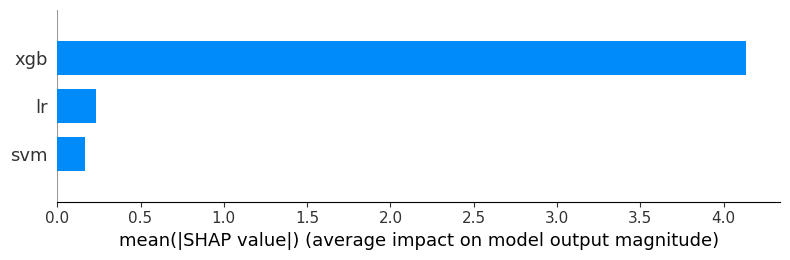

In [11]:
shap.summary_plot(shap_values, X_meta, plot_type="bar")